# Visualización — Producción vs. Deforestación

## Objetivo
 
Traducir los resultados de las queries SQL en gráficos, para comunicar visualmente los 
hallazgos del análisis antes de pasarlos al dashboard de Streamlit.
 
## Gráficos planeados
 
1. **Ranking de producción por provincia** (barras horizontales) — a partir de la query #1
2. **Ranking de deforestación por provincia** (barras horizontales) — a partir de la query #2
3. **Nivel de riesgo por provincia** (barras coloreadas por Alto/Medio/Bajo) — a partir de la query #4
4. **Evolución temporal de producción en provincias de alto riesgo** (líneas) — a partir de la query #6
## Fuente de datos
 
Cada gráfico parte del resultado de una query SQL ya armada en `04_analisis_sql.ipynb`, 
traída nuevamente con `pd.read_sql()` contra `trazabilidad.db`.
 

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px

conexion = sqlite3.connect("../database/trazabilidad.db")

## Gráfico 1 — Ranking de producción por provincia

Total histórico de soja + maíz + trigo producido por provincia (1969-2024), en toneladas. 
Barras horizontales para que se lean bien los nombres largos de provincia.

In [2]:
with open("../sql/ranking_produccion.sql", "r", encoding="utf-8") as archivo:
    query_produccion = archivo.read()

df_ranking_produccion = pd.read_sql(query_produccion, conexion)
df_ranking_produccion.head()

,provincia,total_produccion
0,Buenos Aires,1141283297
1,Córdoba,804752359
2,Santa Fe,600255082
3,Entre Ríos,162184884
4,Santiago del Estero,128408876


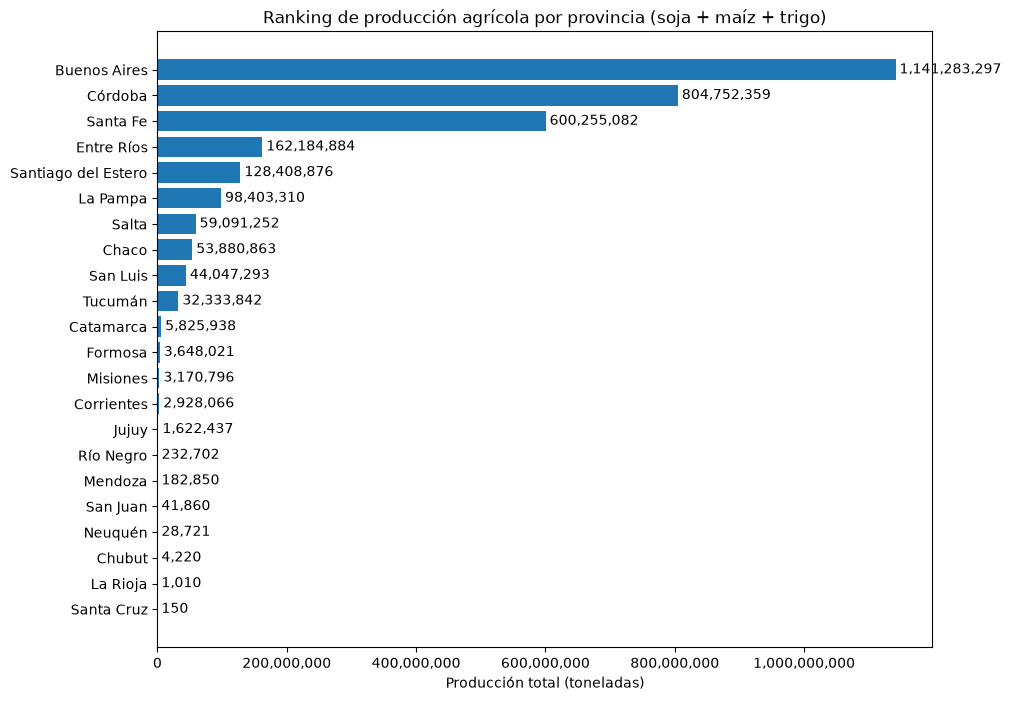

In [3]:

plt.figure(figsize=(10, 8))
barras = plt.barh(df_ranking_produccion['provincia'], df_ranking_produccion['total_produccion'])

for barra in barras:
    ancho = barra.get_width()
    plt.text(
        ancho,
        barra.get_y() + barra.get_height() / 2,
        f' {ancho:,.0f}',
        va='center'
    )

plt.xlabel('Producción total (toneladas)')
plt.title('Ranking de producción agrícola por provincia (soja + maíz + trigo)')
plt.gca().invert_yaxis()


plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.show()

### Conclusión del Grafico 1
Buenos Aires, Córdoba y Santa Fe concentran la gran mayoría de la producción de 
soja/maíz/trigo, muy por encima del resto (Buenos Aires sola produce más que Córdoba y 
Santa Fe juntas). A partir de Entre Ríos hacia abajo, la producción cae drásticamente — 
las provincias del norte (Santiago del Estero, Salta, Chaco), que ya sabemos que tienen 
mayor deforestación, producen relativamente poco en comparación con la zona núcleo pampeana.

## Gráfico 2 — Ranking de deforestación por provincia

Total de hectáreas de bosque nativo perdidas por provincia, sumando las 4 categorías de 
conservación (I, II, III, Sin categoría). Barras horizontales, ordenadas de mayor a menor.

In [4]:
with open("../sql/ranking_deforestacion.sql", "r", encoding="utf-8") as archivo:
    query_deforestacion = archivo.read()

df_ranking_deforestacion = pd.read_sql(query_deforestacion, conexion)
df_ranking_deforestacion.head()

,provincia,total_deforestacion
0,Santiago del Estero,59942.0
1,Formosa,33345.0
2,Chaco,24427.0
3,Salta,13956.0
4,San Luis,9933.0


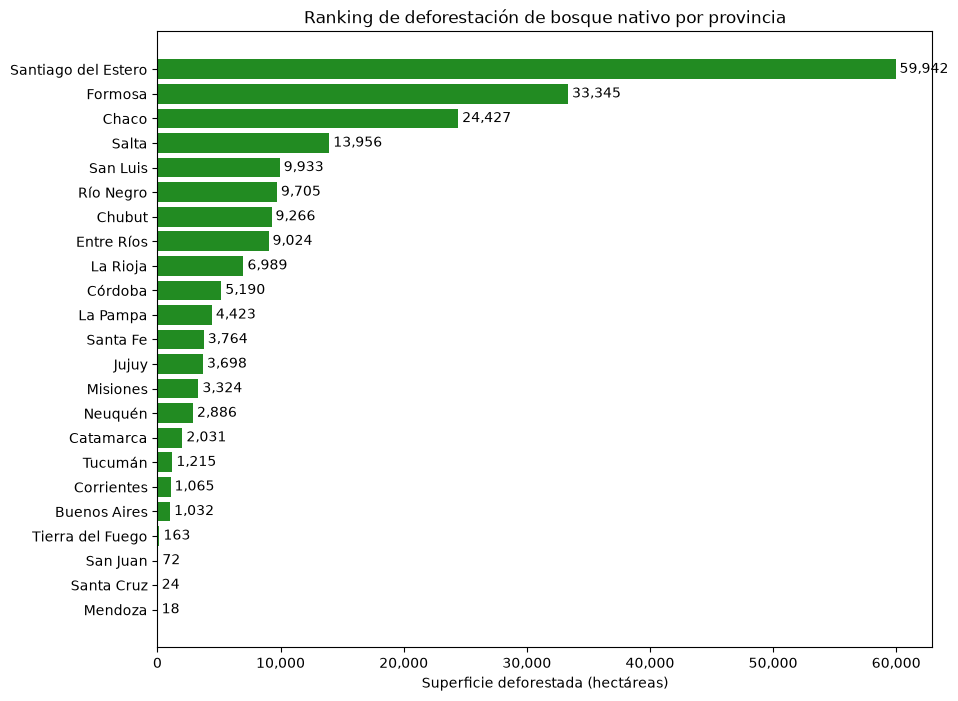

In [5]:
plt.figure(figsize=(10, 8))
barras = plt.barh(
    df_ranking_deforestacion['provincia'], 
    df_ranking_deforestacion['total_deforestacion'],
    color='forestgreen'
)

for barra in barras:
    ancho = barra.get_width()
    plt.text(
        ancho,
        barra.get_y() + barra.get_height() / 2,
        f' {ancho:,.0f}',
        va='center'
    )

plt.xlabel('Superficie deforestada (hectáreas)')
plt.title('Ranking de deforestación de bosque nativo por provincia')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.show()

### Conclusión del Grafico 2

Santiago del Estero, Formosa y Chaco lideran claramente la pérdida de bosque nativo, muy 
por encima del resto — Santiago del Estero casi duplica a Formosa. A partir de Salta hacia 
abajo, los valores caen fuerte. Comparado con el gráfico 1, el patrón es casi inverso: las 
provincias líderes en deforestación (Santiago del Estero, Formosa, Chaco) están lejos de 
ser las líderes en producción.

## Gráfico 3 — Nivel de riesgo por provincia

Mismo ranking de deforestación que el gráfico 2, pero coloreado según la clasificación de 
riesgo (rojo = Alto, amarillo = Medio, verde = Bajo) definida en la query 4. Permite 
identificar de un vistazo qué provincias requieren mayor atención en un análisis de 
trazabilidad agroexportadora.

In [6]:
with open("../sql/clasificacion_riesgo.sql", "r", encoding="utf-8") as archivo:
    query_riesgo = archivo.read()

df_riesgo = pd.read_sql(query_riesgo, conexion)
df_riesgo.head()

,provincia,total_produccion,total_deforestacion,nivel_riesgo
0,Santiago del Estero,128408876,59942.0,Alto
1,Formosa,3648021,33345.0,Alto
2,Chaco,53880863,24427.0,Alto
3,Salta,59091252,13956.0,Medio
4,San Luis,44047293,9933.0,Medio


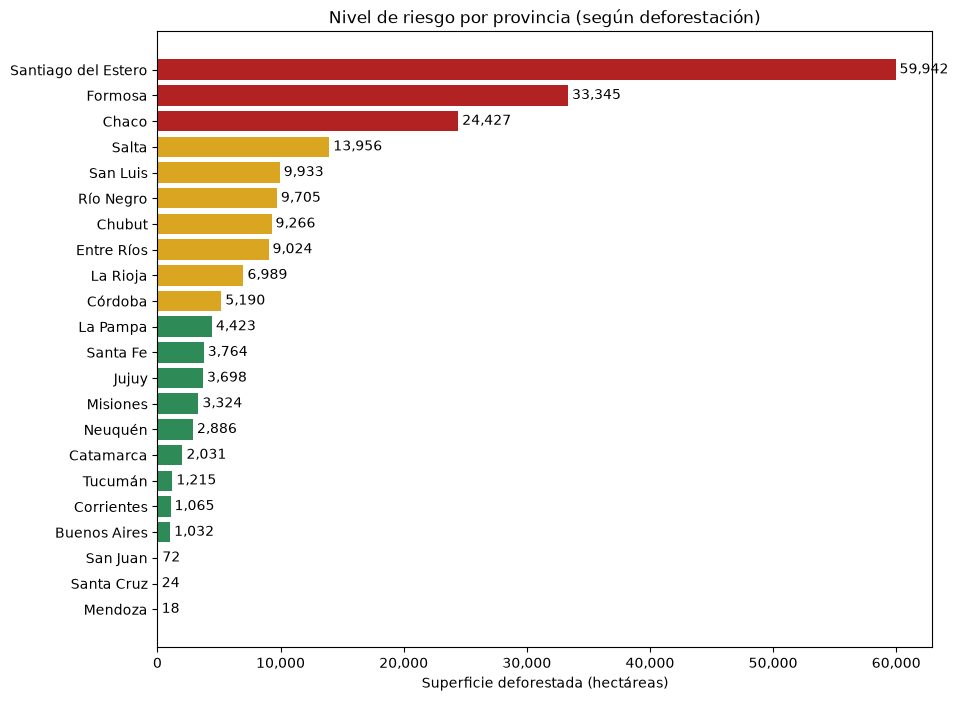

In [7]:
# Mapeamos cada nivel de riesgo a un color
colores_riesgo = {'Alto': 'firebrick', 'Medio': 'goldenrod', 'Bajo': 'seagreen'}

# Creamos una lista de colores, uno por cada provincia, según su nivel de riesgo
colores = df_riesgo['nivel_riesgo'].map(colores_riesgo)

plt.figure(figsize=(10, 8))
barras = plt.barh(df_riesgo['provincia'], df_riesgo['total_deforestacion'], color=colores)

for barra in barras:
    ancho = barra.get_width()
    plt.text(
        ancho,
        barra.get_y() + barra.get_height() / 2,
        f' {ancho:,.0f}',
        va='center'
    )

plt.xlabel('Superficie deforestada (hectáreas)')
plt.title('Nivel de riesgo por provincia (según deforestación)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.show()

### Conclusión del Grafico 3

El corte de riesgo queda muy visual: 3 provincias en "Alto" 
(Santiago del Estero, Formosa, Chaco), 7 en "Medio" (encabezadas por Salta), y el resto en 
"Bajo". Notable que Córdoba, una de las provincias líderes en producción (gráfico 1), 
aparece en nivel "Medio" de riesgo — reforzando que producir mucho no es sinónimo de bajo 
riesgo de deforestación.

## Gráfico 4 — Evolución de producción en provincias de alto riesgo

Serie temporal (1969-2024) de producción de soja/maíz/trigo en las 3 provincias clasificadas 
como "Alto" riesgo: Santiago del Estero, Chaco y Formosa. Permite ver si la expansión 
agrícola en esas zonas es reciente o de larga data.

In [8]:
with open("../sql/evolucion_alto_riesgo.sql", "r", encoding="utf-8") as archivo:
    query_evolucion = archivo.read()

df_evolucion = pd.read_sql(query_evolucion, conexion)
df_evolucion.head()

,provincia,anio,total_produccion
0,Chaco,1969,63060
1,Formosa,1969,15750
2,Santiago del Estero,1969,103326
3,Chaco,1970,98875
4,Formosa,1970,30800


In [9]:
fig_interactivo = px.line(
    df_evolucion,
    x='anio',
    y='total_produccion',
    color='provincia',
    markers=True,
    labels={'anio': 'Año', 'total_produccion': 'Producción (toneladas)', 'provincia': 'Provincia'},
    title='Evolución de producción — provincias de alto riesgo (interactivo)'
)

fig_interactivo.show()

## Conclusión del Grafico 4

Santiago del Estero muestra un crecimiento explosivo a partir del año 2000, pasando de 
prácticamente cero a más de 10.000.000 de toneladas en 2019 — coincide en el tiempo con el 
período de mayor expansión de la frontera agrícola sobre el Chaco Semiárido. Chaco sigue un 
patrón similar pero de menor magnitud. Formosa se mantiene casi plana en todo el período, 
señal de que su presión de deforestación no está tan asociada a estos tres cultivos. Se 
observa además un quiebre marcado en 2008-2009 (caída fuerte en las tres provincias), 
probablemente asociado a la sequía de esa campaña.